# Fitting MOSK GPs using Stan

This notebook demonstrates using Stan in python for fitting MOSK GPs.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import nutpie
import arviz as az

os.environ["TBB_CXX_TYPE"] = "clang"  # or 'gcc'

az.style.use("arviz-vibrant")

In [2]:
filename_stub = "D2-Q1-seed2727-n100-mcar0.2-sigma0.1"
#filename_stub = "D2-Q1-seed6893-n200-mnar0.3-sigma0.1"

D = 2
Q = 1

input_df = pd.read_csv(f'data/{filename_stub}-sim.csv')
input_df.head()

,t,f,y,y_se,d
0,0.000000,-0.643858,-0.528319,0.1,1
1,0.010101,-0.742705,-0.813978,0.1,1
2,0.020202,-0.807881,-0.641318,0.1,1
3,0.030303,-0.837087,-0.963527,0.1,1
4,0.050505,-0.785713,-0.790074,0.1,1


In [10]:
input_df.describe()

,t,f,y,y_se,d
count,151.000000,151.000000,151.000000,1.510000e+02,151.000000
mean,0.508997,0.001548,-0.004908,1.000000e-01,1.450331
std,0.282137,0.966177,0.967788,2.506315e-16,0.499183
min,0.000000,-1.786459,-1.957914,1.000000e-01,1.000000
25%,0.287879,-0.760120,-0.802026,1.000000e-01,1.000000
50%,0.494949,-0.075946,-0.006434,1.000000e-01,1.000000
75%,0.722222,0.785164,0.760469,1.000000e-01,2.000000
max,1.000000,1.772909,1.832566,1.000000e-01,2.000000


In [17]:
sorted(input_df['d'].unique())

[np.int64(1), np.int64(2)]

In [3]:
input_params = pd.read_table(f'data/{filename_stub}-param.tsv')
input_params

,seed,w,Sigma,mu,theta,phi
0,2727,1.01,0.35,3.61,-0.17,0
1,2727,0.96,0.27,4.70,0.08,0


In [4]:
ns = input_df['d'].value_counts().to_numpy()
ns

array([83, 68])

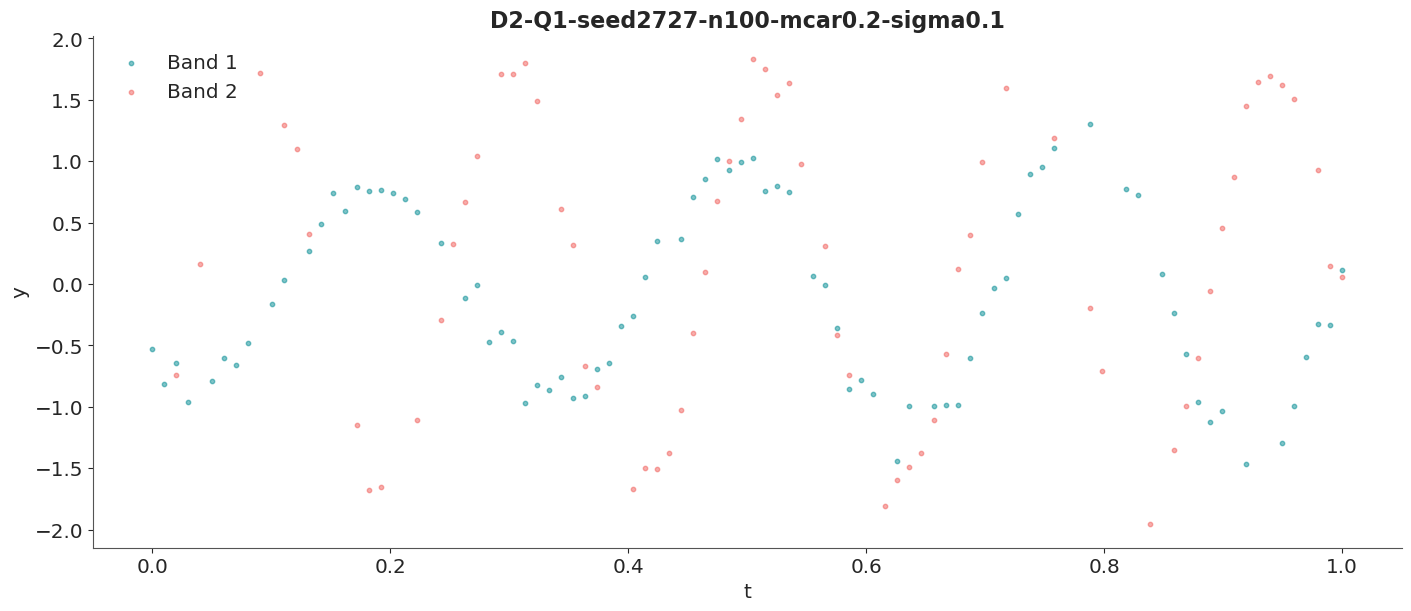

In [18]:
fig, ax = plt.subplots(1, 1, figsize=(14, 6))
legends = []

for band in sorted(input_df['d'].unique()):
    cond = input_df["d"] == band
    xs = input_df.loc[cond, "t"]
    ys = input_df.loc[cond, "y"]
    ax.scatter(xs, ys, s=10, alpha=0.5, marker="o")   
    legends.append(f"Band {band}")

plt.title(f"{filename_stub}")
plt.xlabel("t")
plt.ylabel("y")
plt.legend(legends, loc="upper left");

In [5]:
data = {
    "N": input_df.shape[0],
    "ns": ns,
    "d": input_df['d'],
    "x": input_df['t'],
    "y": input_df['y'],
    "y_se": input_df['y_se']
}

In [6]:
compiled_model = nutpie.compile_stan_model(filename='stan/moskgp-D2.stan').with_data(**data)

In [7]:
trace = nutpie.sample(
    compiled_model=compiled_model, 
    draws=1000,
    tune=1000,
    chains=6,
    cores=6, 
    progress_rate=2000
)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,442,0.19,25
,2000,321,0.18,18
,2000,325,0.17,63
,2000,375,0.13,15
,2000,360,0.14,2
,2000,334,0.20,24


In [19]:
trace

<xarray.DataTree>
Group: /
├── Group: /posterior
│       Dimensions:      (chain: 6, draw: 1000, w_std_dim_0: 2, Sigma_dim_0: 2,
│                         mu_dim_0: 2, theta_dim_0: 2, phi_dim_0: 2, w_dim_0: 2)
│       Coordinates:
│         * chain        (chain) int64 48B 0 1 2 3 4 5
│         * draw         (draw) int64 8kB 0 1 2 3 4 5 6 ... 993 994 995 996 997 998 999
│         * w_std_dim_0  (w_std_dim_0) int64 16B 0 1
│         * Sigma_dim_0  (Sigma_dim_0) int64 16B 0 1
│         * mu_dim_0     (mu_dim_0) int64 16B 0 1
│         * theta_dim_0  (theta_dim_0) int64 16B 0 1
│         * phi_dim_0    (phi_dim_0) int64 16B 0 1
│         * w_dim_0      (w_dim_0) int64 16B 0 1
│       Data variables:
│           w_std        (chain, draw, w_std_dim_0) float64 96kB 0.6508 2.611 ... 1.314
│           Sigma        (chain, draw, Sigma_dim_0) float64 96kB 1.219 ... 0.1698
│           mu           (chain, draw, mu_dim_0) float64 96kB 3.663 4.673 ... 4.661
│           theta        (chain, draw, theta_dim_0) float64 96kB -2.381 ... -0.1728
│           phi          (chain, draw, phi_dim_0) float64 96kB 0.4033 1.025 ... 0.1468
│           deltaTheta   (chain, draw) float64 48kB 5.469 6.516 2.829 ... 0.2429 0.3532
│           w            (chain, draw, w_dim_0) float64 96kB 0.6298 2.526 ... 1.272
│       Attributes:
│           created_at:                 2026-09-19T10:07:01.980317+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.3.0
│           creation_library_language:  Python
│           sample_dims:                ['chain', 'draw']
├── Group: /sample_stats
│       Dimensions:                   (chain: 6, draw: 1000)
│       Coordinates:
│         * chain                     (chain) int64 48B 0 1 2 3 4 5
│         * draw                      (draw) int64 8kB 0 1 2 3 4 ... 995 996 997 998 999
│       Data variables: (12/20)
│           depth                     (chain, draw) uint64 48kB 4 4 4 4 4 ... 3 4 4 4 4
│           maxdepth_reached          (chain, draw) bool 6kB False False ... False False
│           step_size                 (chain, draw) float64 48kB 0.1922 0.188 ... 0.1961
│           transformation_update_id  (chain, draw) int64 48kB 0 0 0 0 0 0 ... 0 0 0 0 0
│           step_size_bar             (chain, draw) float64 48kB 0.1904 ... 0.1991
│           mean_tree_accept          (chain, draw) float64 48kB 0.5912 0.8409 ... 0.955
│           ...                        ...
│           fisher_distance           (chain, draw) float64 48kB 6.059 54.18 ... 27.03
│           transformation_index      (chain, draw) int64 48kB 847 847 847 ... 848 848
│           diverging                 (chain, draw) bool 6kB True False ... False True
│           divergence_draw           (chain, draw) uint64 48kB 1001 0 0 ... 0 0 2000
│           divergence_message        (chain, draw) object 48kB 'Divergence due to la...
│           divergence_energy_error   (chain, draw) float64 48kB 1.342e+03 nan ... nan
│       Attributes:
│           created_at:                  2026-09-19T10:07:01.994934+00:00
│           creation_library:            ArviZ
│           creation_library_version:    1.3.0
│           creation_library_language:   Python
│           sample_dims:                 ['chain', 'draw']
│           inference_library:           nutpie
│           inference_library_version:   0.16.11
│           inference_library_settings:  {"sampler": "nuts", "adaptation": "diag", "s...
├── Group: /warmup_posterior
│       Dimensions:      (chain: 6, draw: 1000, w_std_dim_0: 2, Sigma_dim_0: 2,
│                         mu_dim_0: 2, theta_dim_0: 2, phi_dim_0: 2, w_dim_0: 2)
│       Coordinates:
│         * chain        (chain) int64 48B 0 1 2 3 4 5
│         * draw         (draw) int64 8kB 0 1 2 3 4 5 6 ... 993 994 995 996 997 998 999
│         * w_std_dim_0  (w_std_dim_0) int64 16B 0 1
│         * Sigma_dim_0  (Sigma_dim_0) int64 16B 0 1
│         * mu_dim_0     (mu_dim_0) int64 16B 0 1
│         * theta_dim_0  (

In [20]:
trace.sample_stats.diverging.sum()

<xarray.DataArray 'diverging' ()> Size: 8B
array(2157)

In [21]:
az.ess(trace)

<xarray.DataTree 'posterior'>
Group: /posterior
    Dimensions:      (w_std_dim_0: 2, Sigma_dim_0: 2, mu_dim_0: 2, theta_dim_0: 2,
                      phi_dim_0: 2, w_dim_0: 2)
    Coordinates:
      * w_std_dim_0  (w_std_dim_0) int64 16B 0 1
      * Sigma_dim_0  (Sigma_dim_0) int64 16B 0 1
      * mu_dim_0     (mu_dim_0) int64 16B 0 1
      * theta_dim_0  (theta_dim_0) int64 16B 0 1
      * phi_dim_0    (phi_dim_0) int64 16B 0 1
      * w_dim_0      (w_dim_0) int64 16B 0 1
    Data variables:
        w_std        (w_std_dim_0) float64 16B 274.0 605.4
        Sigma        (Sigma_dim_0) float64 16B 280.4 945.0
        mu           (mu_dim_0) float64 16B 1.558e+03 563.2
        theta        (theta_dim_0) float64 16B 1.136e+03 282.1
        phi          (phi_dim_0) float64 16B 1.506e+03 1.903e+03
        deltaTheta   float64 8B 663.4
        w            (w_dim_0) float64 16B 274.0 605.4

In [22]:
az.rhat(trace)

<xarray.DataTree 'posterior'>
Group: /posterior
    Dimensions:      (w_std_dim_0: 2, Sigma_dim_0: 2, mu_dim_0: 2, theta_dim_0: 2,
                      phi_dim_0: 2, w_dim_0: 2)
    Coordinates:
      * w_std_dim_0  (w_std_dim_0) int64 16B 0 1
      * Sigma_dim_0  (Sigma_dim_0) int64 16B 0 1
      * mu_dim_0     (mu_dim_0) int64 16B 0 1
      * theta_dim_0  (theta_dim_0) int64 16B 0 1
      * phi_dim_0    (phi_dim_0) int64 16B 0 1
      * w_dim_0      (w_dim_0) int64 16B 0 1
    Data variables:
        w_std        (w_std_dim_0) float64 16B 1.019 1.014
        Sigma        (Sigma_dim_0) float64 16B 1.019 1.005
        mu           (mu_dim_0) float64 16B 1.02 1.011
        theta        (theta_dim_0) float64 16B 1.008 1.021
        phi          (phi_dim_0) float64 16B 1.005 1.003
        deltaTheta   float64 8B 1.014
        w            (w_dim_0) float64 16B 1.019 1.014

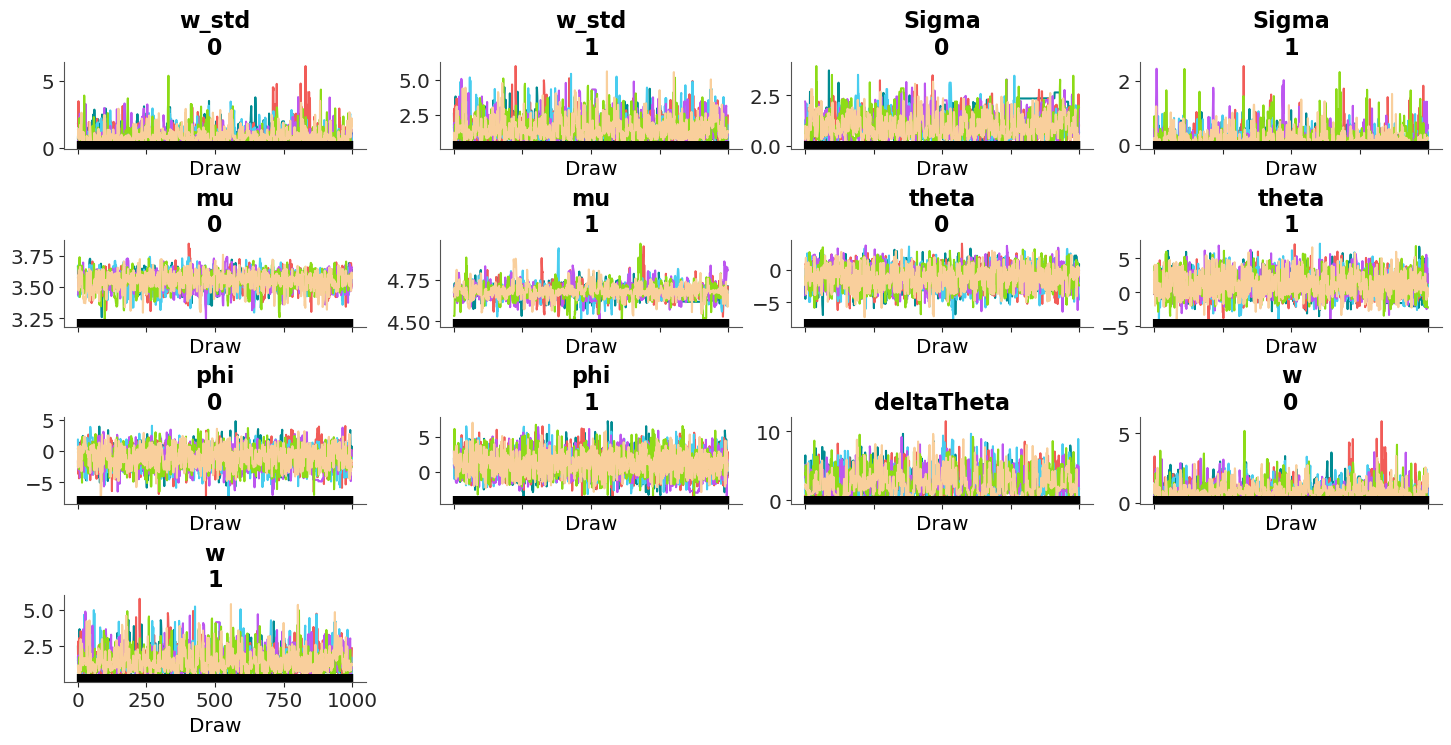

In [24]:
selected_chains = [0,1,2,3,4,5]
az.plot_trace(trace.sel(chain = selected_chains));

In [25]:
az.diagnose(trace.sel(chain = selected_chains))

Divergences
2157 of 6000 (35.95%) transitions ended with a divergence.
These divergent transitions indicate that HMC is not fully able to explore the posterior distribution.
Try increasing adapt delta closer to 1.
If this doesn't remove all divergences, try to reparameterize the model.

E-BFMI
E-BFMI satisfactory for all chains.

ESS
The following parameters have fewer than 600 effective samples:
  w_std, Sigma, mu, theta, w
This suggests that the sampler may not have fully explored the posterior distribution for this parameter.
Consider reparameterizing the model or increasing the number of samples.

R-hat
The following parameters have R-hat values greater than 1.01:
  w_std, Sigma, mu, theta, deltaTheta, w
Such high values indicate incomplete mixing and biased estimation.
You should consider regularizing your model with additional prior information or a more effective parameterization.


True

In [26]:
az.summary(trace.sel(chain = selected_chains))

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
w_std[0],0.87,0.53,0.34,1.9,273,107,1.02,0.021,0.021
w_std[1],1.5,0.77,0.64,2.9,605,140,1.01,0.025,0.019
Sigma[0],1.04,0.62,0.26,2.3,280,93,1.02,0.044,0.039
Sigma[1],0.19,0.23,0.0084,0.6,944,1186,1.00,0.0065,0.011
mu[0],3.553,0.069,3.4,3.7,1557,1463,1.02,0.0018,0.0017
mu[1],4.678,0.044,4.6,4.7,563,92,1.01,0.0017,0.0019
theta[0],-1.24,1.65,-3.8,1.4,1135,1358,1.01,0.05,0.023
theta[1],1.1,1.67,-1.6,3.8,282,264,1.02,0.097,0.031
phi[0],-1.12,1.66,-3.9,1.6,1505,1172,1.01,0.043,0.032
phi[1],1.16,1.67,-1.5,3.8,1903,1669,1.00,0.038,0.037


In [27]:
input_params

,seed,w,Sigma,mu,theta,phi
0,2727,1.01,0.35,3.61,-0.17,0
1,2727,0.96,0.27,4.70,0.08,0


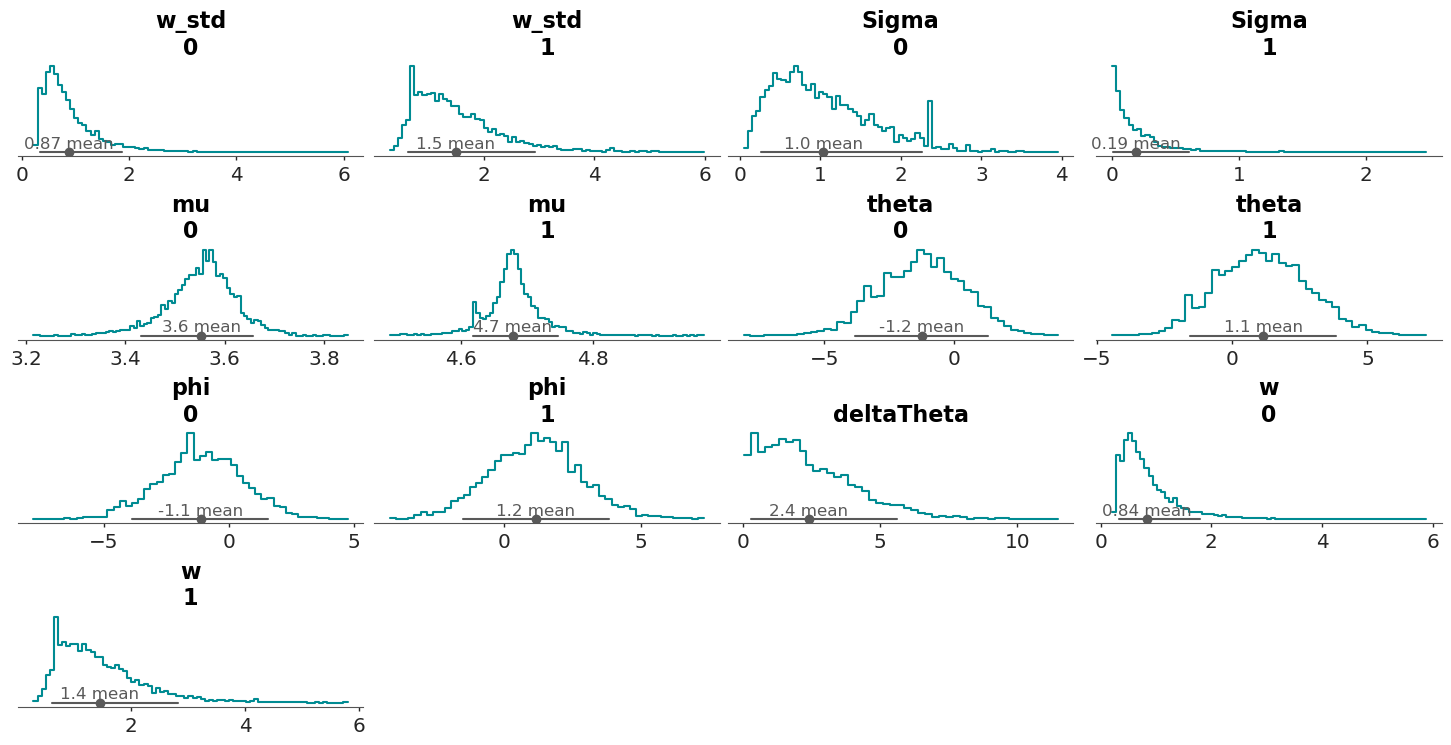

In [28]:
az.plot_dist(trace.sel(chain = selected_chains), kind="hist");

In [32]:
trace.sel(chain = selected_chains).to_netcdf(f'nc/{filename_stub}.nc')